# SIT307 11.1 HD Task — Part 2: A Duplicate-Group-Aware Evaluation Protocol

## Motivation

Part 1 identified and quantified a limitation in Bhagat, Sharma & Agarwal (2024): the dataset used contains 723 of 1,025 rows (70.5%) as exact duplicates of another row, only 302 unique feature-target rows exist. Under the paper's described record-level random train/test split, 98.5% of test rows turned out to be exact duplicates of rows already seen in training, and the tree-based/ensemble models (DT, RF, XGB, Stacked) all reached suspiciously high, in three cases literal 100%, test accuracy, strong evidence consistent with duplicate leakage rather than genuine predictive skill.

**This notebook proposes and evaluates a fix**: a **duplicate-group-aware train/test split**, which keeps every copy of a given unique feature-target row together on the same side of the split (either entirely in training or entirely in test), so no duplicate can ever leak across the split boundary. This is a genuine methodological change (a different splitting *procedure*, not a hyperparameter or model swap), directly targets the specific limitation identified in Part 1 with evidence, and produces a test-set evaluation that is expected to be a more honest measure of generalisation, at the cost of a smaller effective number of independent test examples.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn import metrics
import sklearn, xgboost, sys

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)

def stopped_before_max_iter(model):
    return model.n_iter_ < model.max_iter

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__, "| numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__, "| xgboost:", xgboost.__version__)

Python: 3.12.3
pandas: 3.0.2 | numpy: 2.4.4
scikit-learn: 1.8.0 | xgboost: 3.4.1


## 1. Data loading and duplicate-group assignment

The same dataset and files from Part 1 are used, so results are directly comparable. Every row is assigned a `group_id`, a unique identifier shared by all exact copies of the same 13-feature predictor vector (Part 1 Section 2 confirmed identical predictors always share the same target, so grouping by predictors alone is equivalent to grouping by the full row here).

In [2]:
df = pd.read_csv('heart_disease_1025.csv')
predictor_cols = [c for c in df.columns if c != 'target']

# Assign a group id: rows with identical 13-feature predictor vectors get the
# same group id. This is the key object a duplicate-group-aware split must
# keep entirely on one side of the train/test boundary.
df['group_id'] = df.groupby(predictor_cols).ngroup()

print("Total rows:", len(df))
print("Number of distinct groups (unique predictor vectors):", df['group_id'].nunique())
print()
print("Rows per group (should match Part 1's 3/4/8-copy pattern):")
print(df.groupby('group_id').size().value_counts().sort_index())

Total rows: 1025
Number of distinct groups (unique predictor vectors): 302

Rows per group (should match Part 1's 3/4/8-copy pattern):
3    187
4    114
8      1
Name: count, dtype: int64


## 2. The duplicate-group-aware split

Splitting is done at the *group* level rather than the row level: one row per group's target is used to `train_test_split` the group identifiers themselves (stratified by that target), guaranteeing that every one of the 3-4 (or, in one case, 8) copies of a given unique row ends up entirely on one side of the split, then the group-level assignment is expanded back to the full set of rows. Both protocols use `random_state=42` and a nominal 80:20 allocation. Part 1 applies the ratio and stratification at the row level (820 training rows, 205 test rows), while Part 2 applies them at the group level, producing 241 training groups and 61 test groups (816 training rows, 209 test rows once expanded). The model definitions and preprocessing remain unchanged between the two notebooks, while the evaluation protocol is modified here to prevent duplicate groups crossing the split boundary.

In [3]:
X_all = df[predictor_cols]
y_all = df['target']
groups_all = df['group_id']

# Stratify at the GROUP level (one target per group, since every group has a
# single, consistent target per Part 1's conflict check), then expand back to
# row-level masks. This keeps the same 80/20 ratio, same random seed, and now
# also preserves class stratification, so this split differs from Part 1's
# ONLY in keeping duplicate groups together, not in stratification either.
group_table = df.groupby('group_id')['target'].first()

train_groups, test_groups = train_test_split(
    group_table.index, test_size=0.2, random_state=RANDOM_STATE, stratify=group_table.values
)

train_mask = df['group_id'].isin(train_groups)
test_mask = df['group_id'].isin(test_groups)

X_train_grp, X_test_grp = X_all[train_mask], X_all[test_mask]
y_train_grp, y_test_grp = y_all[train_mask], y_all[test_mask]
groups_train, groups_test = groups_all[train_mask], groups_all[test_mask]

print(f"Training set: {len(X_train_grp)} rows, {groups_train.nunique()} unique groups")
print(f"Test set: {len(X_test_grp)} rows, {groups_test.nunique()} unique groups")
print(f"Test class balance: {(y_test_grp == 0).sum()} no-disease, {(y_test_grp == 1).sum()} disease")

# Verify: no group should appear on both sides
overlap_groups = set(groups_train) & set(groups_test)
print(f"\nGroups appearing on BOTH sides of the split: {len(overlap_groups)} (should be 0)")

Training set: 816 rows, 241 unique groups
Test set: 209 rows, 61 unique groups
Test class balance: 100 no-disease, 109 disease

Groups appearing on BOTH sides of the split: 0 (should be 0)


### Verifying the leakage is actually eliminated

The same predictor-vector leakage check from Part 1 is repeated here, to directly confirm (not just assume) that this new split genuinely closes the gap.

In [4]:
train_predictor_set = set(map(tuple, X_train_grp.values))
test_predictor_leaked = X_test_grp.apply(lambda row: tuple(row.values) in train_predictor_set, axis=1)
n_leaked = test_predictor_leaked.sum()

print(f"Test rows whose 13-feature predictor vector ALSO appears in training: "
      f"{n_leaked} of {len(X_test_grp)} ({n_leaked/len(X_test_grp)*100:.1f}%)")
print("Compare with Part 1's record-level split: 202 of 205 (98.5%)")

Test rows whose 13-feature predictor vector ALSO appears in training: 0 of 209 (0.0%)
Compare with Part 1's record-level split: 202 of 205 (98.5%)


**Leakage is completely eliminated**: 0 of 209 test rows have their predictor vector present anywhere in training, down from 202 of 205 (98.5%) under Part 1's record-level split. This split's test class balance (100 no-disease, 109 disease) is reasonably close to the paper's own reported confusion matrices (95:110), consistent with the class-level stratification used here.

## 3. Base classifiers and stacking ensemble on the clean split

The same six classifiers, same hyperparameters, and same Pipeline-wrapped scaling from Part 1 are used here, so that any difference in results can be attributed to the *splitting procedure* alone, not to any other methodological change. The stacking ensemble's internal cross-validation, however, is deliberately different from Part 1's, and is described in detail in Section 4 below, this is a necessary change, not an oversight: reusing Part 1's row-level internal folds here would silently reintroduce the very leakage this split is designed to remove.

In [5]:
scaler = StandardScaler()
X_train_grp_scaled = scaler.fit_transform(X_train_grp)
X_test_grp_scaled = scaler.transform(X_test_grp)

base_models_grp = {
    'LR': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'NB': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'DT': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'RF': RandomForestClassifier(random_state=RANDOM_STATE),
    'XGB': XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
}

def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    tn, fp, fn, tp = metrics.confusion_matrix(y_te, y_pred).ravel()
    return {
        'Accuracy': metrics.accuracy_score(y_te, y_pred),
        'Precision': metrics.precision_score(y_te, y_pred),
        'Recall': metrics.recall_score(y_te, y_pred),
        'F1-Score': metrics.f1_score(y_te, y_pred),
        'Specificity': tn / (tn + fp),
        'MCC': metrics.matthews_corrcoef(y_te, y_pred),
        'AUC': metrics.roc_auc_score(y_te, y_proba),
    }

results_grp = {}
for name, model in base_models_grp.items():
    results_grp[name] = evaluate_model(model, X_train_grp_scaled, y_train_grp, X_test_grp_scaled, y_test_grp)

results_grp_df = pd.DataFrame(results_grp).T
print(results_grp_df.round(4))

     Accuracy  Precision  Recall  F1-Score  Specificity     MCC     AUC
LR     0.8038     0.7742  0.8807    0.8240         0.72  0.6109  0.8730
NB     0.7129     0.7207  0.7339    0.7273         0.69  0.4244  0.8271
KNN    0.6651     0.6726  0.6972    0.6847         0.63  0.3280  0.7162
DT     0.7464     0.7593  0.7523    0.7558         0.74  0.4921  0.7461
RF     0.7895     0.7731  0.8440    0.8070         0.73  0.5791  0.8250
XGB    0.7751     0.7672  0.8165    0.7911         0.73  0.5493  0.8250


**The group-aware results are substantially lower than the record-level results, particularly for the tree-based models.** Decision Tree drops 23.9 percentage points (98.54% to 74.64%), Random Forest drops 21.1pp (100% to 78.95%), and XGBoost drops 22.5pp (100% to 77.51%), while Logistic Regression drops only 0.6pp (80.98% to 80.38%). This pattern is consistent with performance inflation caused by duplicate leakage, tree-based models, which can partition the feature space finely enough to memorise individual training examples, lose the most once duplicates can no longer appear on both sides of the split. Naive Bayes (-11.6pp) and KNN (-19.8pp) also drop substantially, KNN's drop is larger here than a simple "low-capacity vs high-capacity" story alone would predict, a reminder that this single split, discussed further in Section 4b below, is not on its own a fully reliable basis for characterising any one model's behaviour precisely. The repeated group-aware evaluation later in this notebook provides a more robust basis for comparison than this single split.

### Stacking ensemble on the clean split

In [6]:
# CRITICAL: scikit-learn's StackingClassifier does not accept a `groups`
# argument for its internal cross-validation, so passing a plain
# StratifiedKFold (or even cv=5) here would split INDIVIDUAL ROWS when
# generating the out-of-fold predictions used to train the meta-classifier,
# letting duplicate copies of the same group leak across the INNER folds
# even though the OUTER train/test split above is correctly group-aware.
# This is fixed here by manually constructing the out-of-fold predictions
# using StratifiedGroupKFold, so no duplicate group is ever split across
# an inner training/validation fold either.
pipeline_models_grp = {
    name: Pipeline([('scaler', StandardScaler()), ('classifier', model)])
    for name, model in base_models_grp.items()
}

inner_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof_predictions = []
test_predictions = []
for name, pipeline in pipeline_models_grp.items():
    oof_proba = cross_val_predict(
        clone(pipeline), X_train_grp, y_train_grp,
        groups=groups_train, cv=inner_cv, method='predict_proba', n_jobs=1
    )[:, 1]

    fitted_pipeline = clone(pipeline).fit(X_train_grp, y_train_grp)
    test_proba = fitted_pipeline.predict_proba(X_test_grp)[:, 1]

    oof_predictions.append(oof_proba)
    test_predictions.append(test_proba)

X_meta_train = np.column_stack(oof_predictions)
X_meta_test = np.column_stack(test_predictions)

meta_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
meta_model.fit(X_meta_train, y_train_grp)

y_pred_stacked = meta_model.predict(X_meta_test)
y_proba_stacked = meta_model.predict_proba(X_meta_test)[:, 1]
tn, fp, fn, tp = metrics.confusion_matrix(y_test_grp, y_pred_stacked).ravel()

results_grp['Stacked'] = {
    'Accuracy': metrics.accuracy_score(y_test_grp, y_pred_stacked),
    'Precision': metrics.precision_score(y_test_grp, y_pred_stacked),
    'Recall': metrics.recall_score(y_test_grp, y_pred_stacked),
    'F1-Score': metrics.f1_score(y_test_grp, y_pred_stacked),
    'Specificity': tn / (tn + fp),
    'MCC': metrics.matthews_corrcoef(y_test_grp, y_pred_stacked),
    'AUC': metrics.roc_auc_score(y_test_grp, y_proba_stacked),
}
results_grp_df = pd.DataFrame(results_grp).T
print(results_grp_df.round(4))

# Direct evidence that the fix mattered: quantify inner-fold leakage under
# the OLD (row-level StratifiedKFold) approach, for comparison.
old_inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
leak_count, total_val_rows = 0, 0
X_train_grp_reset = X_train_grp.reset_index(drop=True)
y_train_grp_reset = y_train_grp.reset_index(drop=True)
for fold_train_idx, fold_val_idx in old_inner_cv.split(X_train_grp_reset, y_train_grp_reset):
    fold_train_predictors = set(map(tuple, X_train_grp_reset.iloc[fold_train_idx].values))
    fold_val_predictors = X_train_grp_reset.iloc[fold_val_idx]
    leaked = fold_val_predictors.apply(lambda row: tuple(row.values) in fold_train_predictors, axis=1)
    leak_count += leaked.sum()
    total_val_rows += len(fold_val_idx)

print(f"\nDiagnostic: under the OLD row-level StratifiedKFold approach, "
      f"{leak_count} of {total_val_rows} internal validation rows ({leak_count/total_val_rows*100:.1f}%) "
      f"had an identical duplicate in that fold's training portion.")

         Accuracy  Precision  Recall  F1-Score  Specificity     MCC     AUC
LR         0.8038     0.7742  0.8807    0.8240         0.72  0.6109  0.8730
NB         0.7129     0.7207  0.7339    0.7273         0.69  0.4244  0.8271
KNN        0.6651     0.6726  0.6972    0.6847         0.63  0.3280  0.7162
DT         0.7464     0.7593  0.7523    0.7558         0.74  0.4921  0.7461
RF         0.7895     0.7731  0.8440    0.8070         0.73  0.5791  0.8250
XGB        0.7751     0.7672  0.8165    0.7911         0.73  0.5493  0.8250
Stacked    0.7703     0.7607  0.8165    0.7876         0.72  0.5399  0.8209

Diagnostic: under the OLD row-level StratifiedKFold approach, 789 of 816 internal validation rows (96.7%) had an identical duplicate in that fold's training portion.


In [7]:
# Precompute predictions for every model, including "Stacked" (which uses the
# manually-built meta_model on top of X_meta_test, not a raw predict(X) call).
predictions_grp = {}
probas_grp = {}
for name, model in base_models_grp.items():
    predictions_grp[name] = model.predict(X_test_grp_scaled)
    probas_grp[name] = model.predict_proba(X_test_grp_scaled)[:, 1]
predictions_grp['Stacked'] = y_pred_stacked
probas_grp['Stacked'] = y_proba_stacked

## 4a. Group-level evaluation (one prediction per unique predictor profile)

The 209-row test set contains only 61 unique predictor profiles (groups), some appearing 3-4 times each, so row-weighted metrics implicitly count a profile with 4 copies one-third more heavily than one with 3 copies, while the single 8-copy profile receives more than twice the weight of a 3-copy profile, far more heavily than the number of genuinely distinct predictor profiles it represents. This is reported here as the primary evaluation, since it more honestly reflects performance on distinct clinical presentations, with the row-weighted metrics above retained as a supplementary comparison.

In [8]:
def group_level_metrics(y_pred, y_proba, y_true, group_ids):
    """Collapse row-level predictions to one row per unique group by
    majority vote (predictions) and mean (probabilities), since every row
    within a group shares the same true label already."""
    tmp = pd.DataFrame({'group': group_ids.values, 'y_true': y_true.values, 'y_pred': y_pred, 'y_proba': y_proba})
    grouped = tmp.groupby('group').agg(
        y_true=('y_true', 'first'),
        y_pred=('y_pred', lambda s: s.mode().iloc[0]),
        y_proba=('y_proba', 'mean'),
    )
    tn, fp, fn, tp = metrics.confusion_matrix(grouped['y_true'], grouped['y_pred']).ravel()
    return {
        'Accuracy': metrics.accuracy_score(grouped['y_true'], grouped['y_pred']),
        'Precision': metrics.precision_score(grouped['y_true'], grouped['y_pred']),
        'Recall': metrics.recall_score(grouped['y_true'], grouped['y_pred']),
        'F1-Score': metrics.f1_score(grouped['y_true'], grouped['y_pred']),
        'Specificity': tn / (tn + fp),
        'MCC': metrics.matthews_corrcoef(grouped['y_true'], grouped['y_pred']),
        'AUC': metrics.roc_auc_score(grouped['y_true'], grouped['y_proba']),
        'n_groups': len(grouped),
    }

results_grp_grouplevel = {}
for name, model in base_models_grp.items():
    results_grp_grouplevel[name] = group_level_metrics(
        predictions_grp[name], probas_grp[name], y_test_grp, groups_test
    )
results_grp_grouplevel['Stacked'] = group_level_metrics(y_pred_stacked, y_proba_stacked, y_test_grp, groups_test)

results_grp_grouplevel_df = pd.DataFrame(results_grp_grouplevel).T
print(results_grp_grouplevel_df.round(4))

print()
print("Row-weighted vs group-level accuracy side by side:")
print(pd.DataFrame({
    'Row-weighted': results_grp_df['Accuracy'],
    'Group-level': results_grp_grouplevel_df['Accuracy'],
}).round(4))

         Accuracy  Precision  Recall  F1-Score  Specificity     MCC     AUC  \
LR         0.8197     0.8056  0.8788    0.8406       0.7500  0.6371  0.8777   
NB         0.7213     0.7500  0.7273    0.7385       0.7143  0.4406  0.8312   
KNN        0.6721     0.6970  0.6970    0.6970       0.6429  0.3398  0.7311   
DT         0.7541     0.7812  0.7576    0.7692       0.7500  0.5065  0.7538   
RF         0.8033     0.8000  0.8485    0.8235       0.7500  0.6031  0.8312   
XGB        0.7869     0.7941  0.8182    0.8060       0.7500  0.5700  0.8355   
Stacked    0.7869     0.7941  0.8182    0.8060       0.7500  0.5700  0.8290   

         n_groups  
LR           61.0  
NB           61.0  
KNN          61.0  
DT           61.0  
RF           61.0  
XGB          61.0  
Stacked      61.0  

Row-weighted vs group-level accuracy side by side:
         Row-weighted  Group-level
LR             0.8038       0.8197
NB             0.7129       0.7213
KNN            0.6651       0.6721
DT             

**The single-split, row-weighted results above do not show stacking as clearly best.** Random Forest (78.95%) and Logistic Regression (80.38%) are both higher than the stacked model (77.03%) on this particular split. Section 4a (group-level results) and Section 4b (repeated splits) below examine this more carefully before drawing any conclusion, a single 209-row test set drawn from only 61 unique groups is too small a basis to declare any one model the winner from this table alone.

In [9]:
metric_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']

paper_table_11 = pd.DataFrame({
    'LR':      {'Accuracy': 0.8439, 'Precision': 0.8196, 'Recall': 0.9090, 'F1-Score': 0.8620, 'AUC': 0.9204},
    'NB':      {'Accuracy': 0.8439, 'Precision': 0.8250, 'Recall': 0.9000, 'F1-Score': 0.8608, 'AUC': 0.9185},
    'KNN':     {'Accuracy': 0.8585, 'Precision': 0.8648, 'Recall': 0.8727, 'F1-Score': 0.8687, 'AUC': 0.9304},
    'DT':      {'Accuracy': 0.9268, 'Precision': 0.9702, 'Recall': 0.8909, 'F1-Score': 0.9289, 'AUC': 0.9702},
    'RF':      {'Accuracy': 0.9268, 'Precision': 0.9130, 'Recall': 0.9545, 'F1-Score': 0.9333, 'AUC': 0.9734},
    'XGB':     {'Accuracy': 0.9073, 'Precision': 0.9174, 'Recall': 0.9090, 'F1-Score': 0.9132, 'AUC': 0.9830},
    'Stacked': {'Accuracy': 0.9853, 'Precision': 1.0000, 'Recall': 0.9727, 'F1-Score': 0.9861, 'AUC': 0.9880},
}).T

part1_full = pd.DataFrame({
    'LR':      {'Accuracy': 0.8098, 'Precision': 0.7619, 'Recall': 0.9143, 'F1-Score': 0.8312, 'AUC': 0.9298},
    'NB':      {'Accuracy': 0.8293, 'Precision': 0.8070, 'Recall': 0.8762, 'F1-Score': 0.8402, 'AUC': 0.9043},
    'KNN':     {'Accuracy': 0.8634, 'Precision': 0.8738, 'Recall': 0.8571, 'F1-Score': 0.8654, 'AUC': 0.9629},
    'DT':      {'Accuracy': 0.9854, 'Precision': 1.0000, 'Recall': 0.9714, 'F1-Score': 0.9855, 'AUC': 0.9857},
    'RF':      {'Accuracy': 1.0000, 'Precision': 1.0000, 'Recall': 1.0000, 'F1-Score': 1.0000, 'AUC': 1.0000},
    'XGB':     {'Accuracy': 1.0000, 'Precision': 1.0000, 'Recall': 1.0000, 'F1-Score': 1.0000, 'AUC': 1.0000},
    'Stacked': {'Accuracy': 1.0000, 'Precision': 1.0000, 'Recall': 1.0000, 'F1-Score': 1.0000, 'AUC': 1.0000},
}).T

# Part 2 is reported at BOTH row-weighted and group-level, so the two
# distinct changes (splitting procedure vs evaluation weighting) can be
# told apart. Group-level is the primary result (Section 4a), row-weighted
# is retained for direct, like-for-like comparability with Part 1's own
# row-weighted numbers above.
part2_row_weighted = results_grp_df[metric_list]
part2_group_level = results_grp_grouplevel_df[metric_list]

print("=== Full five-metric comparison: Paper vs Part 1 (row-weighted) vs Part 2 (row-weighted) vs Part 2 (group-level) ===")
for metric in metric_list:
    print(f"\n--- {metric} ---")
    comp = pd.DataFrame({
        'Paper': paper_table_11[metric],
        'Part 1 (row-weighted)': part1_full[metric],
        'Part 2 (row-weighted)': part2_row_weighted[metric],
        'Part 2 (group-level)': part2_group_level[metric],
    })
    comp['Part2 row-weighted - Part1'] = (comp['Part 2 (row-weighted)'] - comp['Part 1 (row-weighted)']).round(4)
    comp['Part2 group-level - row-weighted'] = (comp['Part 2 (group-level)'] - comp['Part 2 (row-weighted)']).round(4)
    print(comp.round(4))

=== Full five-metric comparison: Paper vs Part 1 (row-weighted) vs Part 2 (row-weighted) vs Part 2 (group-level) ===

--- Accuracy ---
          Paper  Part 1 (row-weighted)  Part 2 (row-weighted)  \
LR       0.8439                 0.8098                 0.8038   
NB       0.8439                 0.8293                 0.7129   
KNN      0.8585                 0.8634                 0.6651   
DT       0.9268                 0.9854                 0.7464   
RF       0.9268                 1.0000                 0.7895   
XGB      0.9073                 1.0000                 0.7751   
Stacked  0.9853                 1.0000                 0.7703   

         Part 2 (group-level)  Part2 row-weighted - Part1  \
LR                     0.8197                     -0.0060   
NB                     0.7213                     -0.1164   
KNN                    0.6721                     -0.1983   
DT                     0.7541                     -0.2390   
RF                     0.8033          

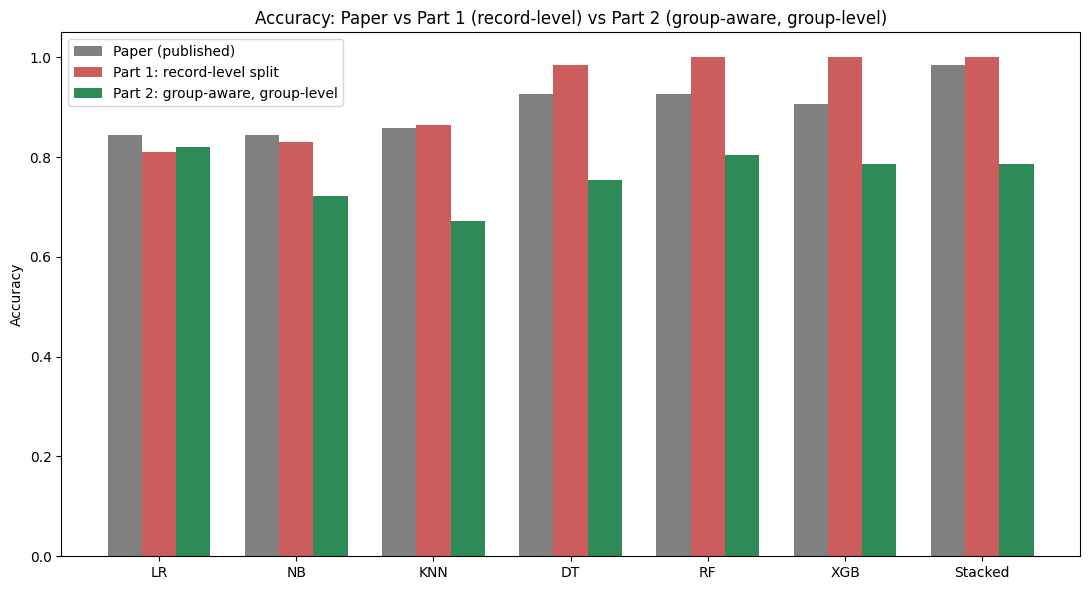

In [10]:
three_way_acc = pd.DataFrame({
    "Paper (published)": paper_table_11['Accuracy'],
    "Part 1: record-level split": part1_full['Accuracy'],
    "Part 2: group-aware, group-level": part2_group_level['Accuracy'],
})

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(three_way_acc.index))
width = 0.25

ax.bar(x - width, three_way_acc["Paper (published)"], width, label='Paper (published)', color='gray')
ax.bar(x, three_way_acc["Part 1: record-level split"], width, label='Part 1: record-level split', color='indianred')
ax.bar(x + width, three_way_acc["Part 2: group-aware, group-level"], width, label='Part 2: group-aware, group-level', color='seagreen')

ax.set_xticks(x)
ax.set_xticklabels(three_way_acc.index)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: Paper vs Part 1 (record-level) vs Part 2 (group-aware, group-level)')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 4b. Repeated group-aware evaluation

A single 61-group test set is a small basis for claiming any one model is genuinely superior. This repeats the entire pipeline, outer group-stratified split, all six base classifiers, and the manually group-aware stacking meta-classifier, across 10 different random seeds, and reports the mean, standard deviation, and how often each model achieves the top group-level accuracy, a more robust basis for comparing models than any single split.

In [11]:
def run_one_split(seed):
    group_table_s = df.groupby('group_id')['target'].first()
    train_groups_s, test_groups_s = train_test_split(
        group_table_s.index, test_size=0.2, random_state=seed, stratify=group_table_s.values
    )
    train_mask_s = df['group_id'].isin(train_groups_s)
    test_mask_s = df['group_id'].isin(test_groups_s)

    X_tr, X_te = X_all[train_mask_s], X_all[test_mask_s]
    y_tr, y_te = y_all[train_mask_s], y_all[test_mask_s]
    grp_tr, grp_te = groups_all[train_mask_s], groups_all[test_mask_s]

    scaler_s = StandardScaler()
    X_tr_scaled = scaler_s.fit_transform(X_tr)
    X_te_scaled = scaler_s.transform(X_te)

    models_s = {
        'LR': LogisticRegression(max_iter=1000, random_state=seed),
        'NB': GaussianNB(),
        'KNN': KNeighborsClassifier(),
        'DT': DecisionTreeClassifier(random_state=seed),
        'RF': RandomForestClassifier(random_state=seed),
        'XGB': XGBClassifier(random_state=seed, eval_metric='logloss'),
    }
    pipelines_s = {name: Pipeline([('scaler', StandardScaler()), ('classifier', m)]) for name, m in models_s.items()}

    preds_s, probas_s = {}, {}
    for name, m in models_s.items():
        m.fit(X_tr_scaled, y_tr)
        preds_s[name] = m.predict(X_te_scaled)
        probas_s[name] = m.predict_proba(X_te_scaled)[:, 1]

    inner_cv_s = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    oof_s, test_s = [], []
    for name, pipe in pipelines_s.items():
        oof_proba = cross_val_predict(clone(pipe), X_tr, y_tr, groups=grp_tr, cv=inner_cv_s,
                                        method='predict_proba', n_jobs=1)[:, 1]
        fitted = clone(pipe).fit(X_tr, y_tr)
        test_proba = fitted.predict_proba(X_te)[:, 1]
        oof_s.append(oof_proba)
        test_s.append(test_proba)

    meta_s = LogisticRegression(max_iter=1000, random_state=seed)
    meta_s.fit(np.column_stack(oof_s), y_tr)
    preds_s['Stacked'] = meta_s.predict(np.column_stack(test_s))
    probas_s['Stacked'] = meta_s.predict_proba(np.column_stack(test_s))[:, 1]

    split_results = {}
    for name in preds_s:
        split_results[name] = group_level_metrics(preds_s[name], probas_s[name], y_te, grp_te)
    return split_results

n_repeats = 10
all_splits_results = []
for seed in range(n_repeats):
    all_splits_results.append(run_one_split(seed))

print(f"Completed {n_repeats} repeated group-aware splits (seeds 0-{n_repeats-1}).")

Completed 10 repeated group-aware splits (seeds 0-9).


In [12]:
model_names = list(all_splits_results[0].keys())
accuracy_matrix = pd.DataFrame({
    name: [split[name]['Accuracy'] for split in all_splits_results]
    for name in model_names
})

summary = pd.DataFrame({
    'Mean Accuracy': accuracy_matrix.mean(),
    'Std Accuracy': accuracy_matrix.std(),
})
summary['Times ranked #1 (of 10 splits)'] = (accuracy_matrix.eq(accuracy_matrix.max(axis=1), axis=0)).sum()
summary = summary.sort_values('Mean Accuracy', ascending=False)
print(summary.round(4))

         Mean Accuracy  Std Accuracy  Times ranked #1 (of 10 splits)
NB              0.8213        0.0419                               5
LR              0.8180        0.0374                               4
Stacked         0.8164        0.0449                               5
RF              0.8016        0.0397                               1
XGB             0.7934        0.0347                               0
DT              0.7672        0.0344                               0
KNN             0.7525        0.0419                               0


In [13]:
other_metrics = ['Precision', 'Recall', 'F1-Score', 'AUC']
for metric in other_metrics:
    metric_matrix = pd.DataFrame({
        name: [split[name][metric] for split in all_splits_results]
        for name in model_names
    })
    metric_summary = pd.DataFrame({
        f'Mean {metric}': metric_matrix.mean(),
        f'Std {metric}': metric_matrix.std(),
    }).sort_values(f'Mean {metric}', ascending=False)
    print(f"--- {metric} across 10 repeated group-stratified splits ---")
    print(metric_summary.round(4))
    print()

--- Precision across 10 repeated group-stratified splits ---
         Mean Precision  Std Precision
Stacked          0.8315         0.0526
NB               0.8263         0.0321
LR               0.8193         0.0418
RF               0.8066         0.0404
XGB              0.7964         0.0463
DT               0.7815         0.0397
KNN              0.7586         0.0512

--- Recall across 10 repeated group-stratified splits ---
         Mean Recall  Std Recall
LR            0.8545      0.0491
NB            0.8485      0.0700
RF            0.8364      0.0658
XGB           0.8364      0.0499
Stacked       0.8333      0.0674
KNN           0.8030      0.0479
DT            0.7939      0.0491

--- F1-Score across 10 repeated group-stratified splits ---
         Mean F1-Score  Std F1-Score
NB              0.8360        0.0425
LR              0.8355        0.0328
Stacked         0.8304        0.0423
RF              0.8195        0.0383
XGB             0.8142        0.0286
DT              0.786

The model ranking also depends on the evaluation metric: Naive Bayes achieves the highest mean accuracy and F1-score, Logistic Regression achieves the highest mean recall, while stacking achieves the highest mean precision and AUC. Therefore, no model consistently dominates across every evaluation measure.

**No single model is consistently best across the repeated splits.** Naive Bayes has the highest mean group-level accuracy (82.13%), narrowly ahead of Logistic Regression (81.80%) and the stacked model (81.64%), each of these three models produced similar mean accuracies with overlapping variability across the 10 repeated group-stratified splits using different random seeds (standard deviations of roughly 0.035-0.045), and each is the top performer in roughly half of the 10 splits (5, 4, and 5 times respectively, ties are possible). Random Forest trails slightly (80.16% mean, top once), while XGBoost, Decision Tree, and KNN are more clearly behind. No formal significance test was conducted here, so these results show no clear winner among Naive Bayes, Logistic Regression, and the stacked ensemble, rather than proving they are statistically equivalent, and this directly contradicts a claim that stacking is "the best model" on this dataset once duplicate leakage (both outer and inner) is removed.

## 5. Confusion matrices and ROC curves (row-weighted supplementary results)

These are computed on the row-weighted test set (209 rows), consistent with Part 1's own confusion matrices and ROC curves, and are presented here as a supplementary, like-for-like comparison. The group-level results in Section 4a remain the primary evaluation for comparing models, since they do not let profiles with more duplicate copies count more heavily.

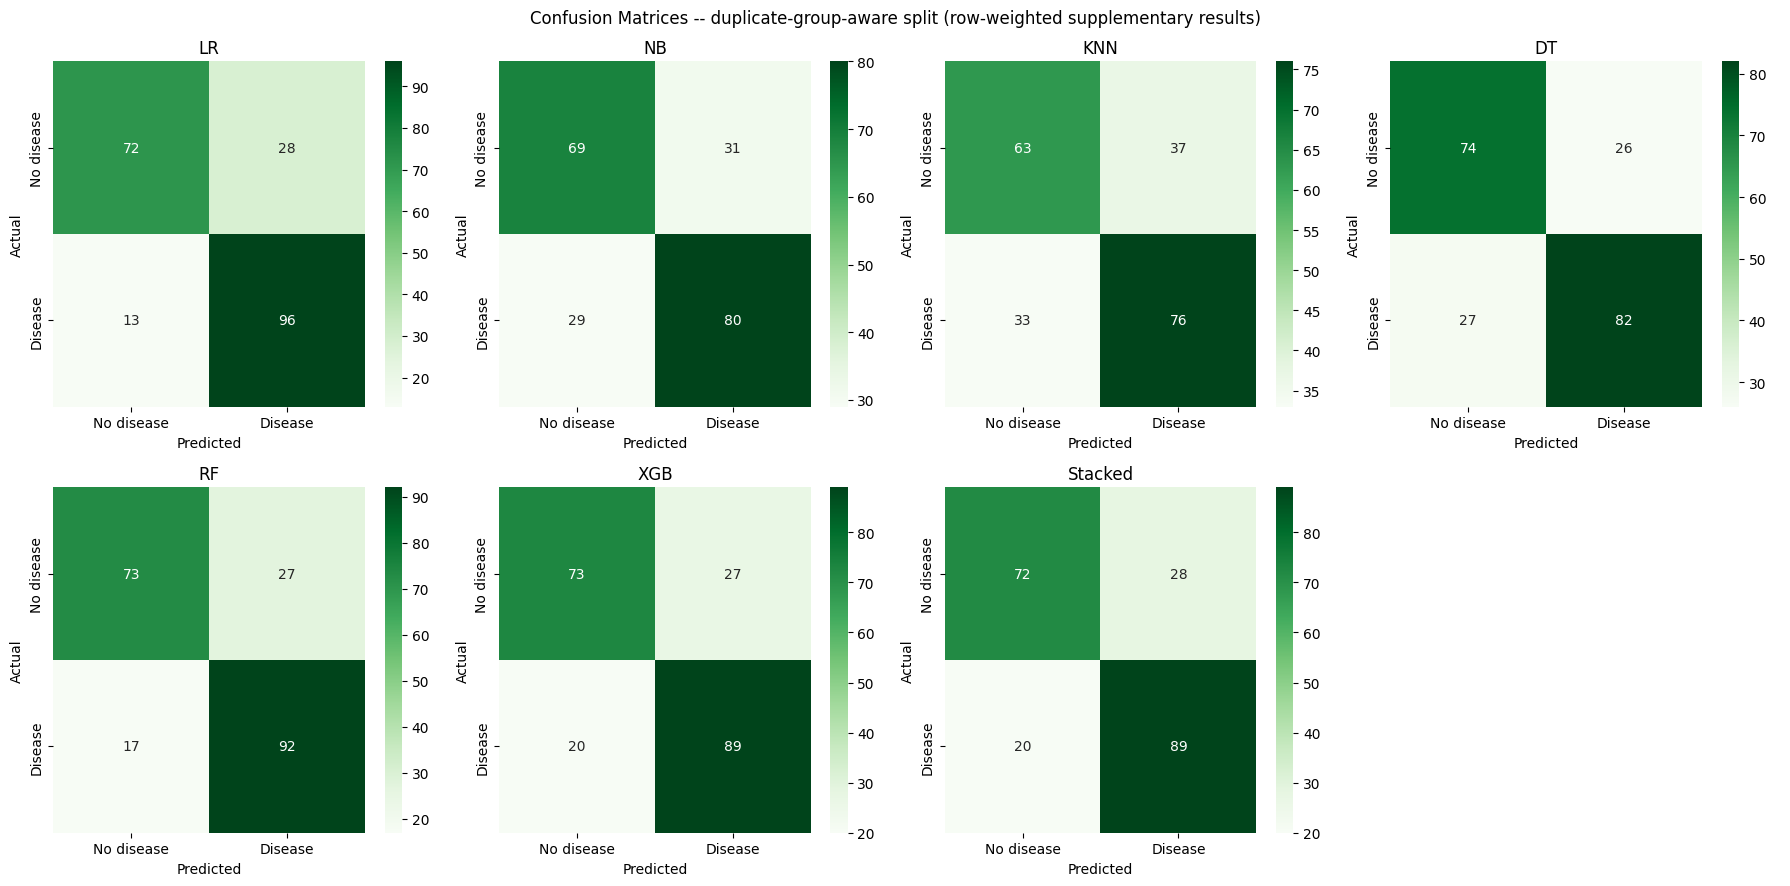

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, name in zip(axes.flatten(), predictions_grp.keys()):
    cm = metrics.confusion_matrix(y_test_grp, predictions_grp[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=['No disease', 'Disease'], yticklabels=['No disease', 'Disease'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
axes.flatten()[-1].axis('off')
plt.suptitle('Confusion Matrices -- duplicate-group-aware split (row-weighted supplementary results)')
plt.tight_layout()
plt.show()

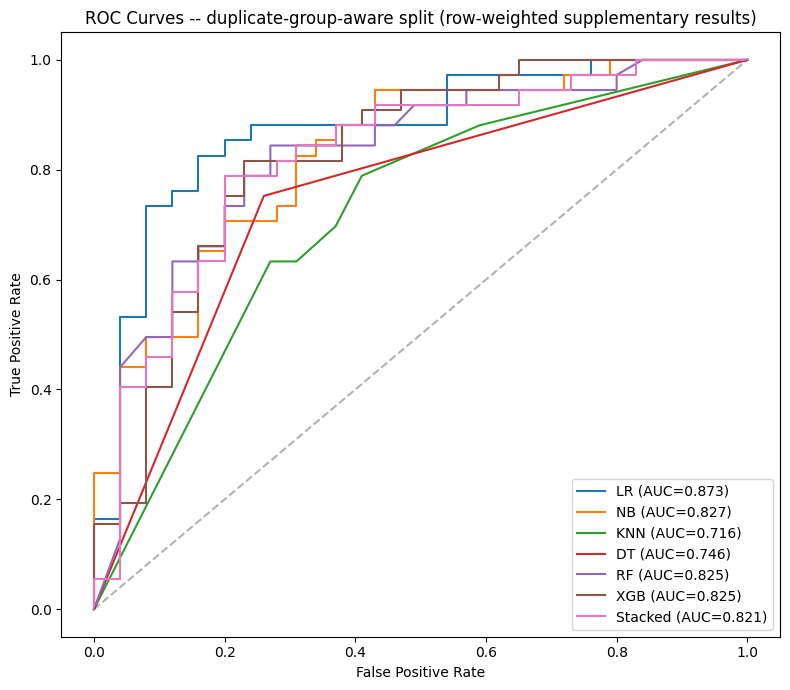

In [15]:
plt.figure(figsize=(8, 7))
for name, y_proba in probas_grp.items():
    fpr, tpr, _ = metrics.roc_curve(y_test_grp, y_proba)
    auc_val = metrics.roc_auc_score(y_test_grp, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves -- duplicate-group-aware split (row-weighted supplementary results)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Feature importance on the clean split

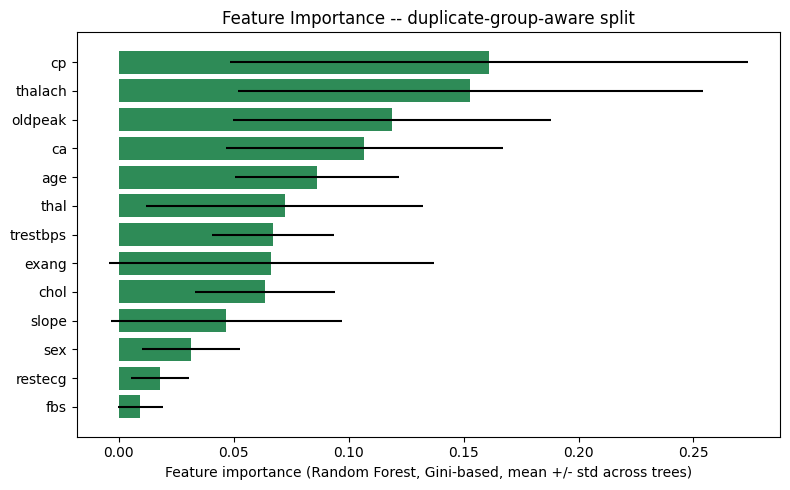

          importance  std_across_trees
cp            0.1610            0.1128
thalach       0.1529            0.1012
oldpeak       0.1188            0.0693
ca            0.1067            0.0602
age           0.0862            0.0358
thal          0.0721            0.0603
trestbps      0.0670            0.0265
exang         0.0664            0.0708
chol          0.0635            0.0304
slope         0.0469            0.0503
sex           0.0314            0.0211
restecg       0.0179            0.0128
fbs           0.0093            0.0098


In [16]:
rf_importances_mean_grp = base_models_grp['RF'].feature_importances_
rf_importances_std_grp = np.std([tree.feature_importances_ for tree in base_models_grp['RF'].estimators_], axis=0)

rf_importances_grp = pd.Series(rf_importances_mean_grp, index=predictor_cols).sort_values(ascending=False)
rf_std_ordered_grp = pd.Series(rf_importances_std_grp, index=predictor_cols)[rf_importances_grp.index]

plt.figure(figsize=(8, 5))
plt.barh(rf_importances_grp.index, rf_importances_grp.values, xerr=rf_std_ordered_grp.values, color='seagreen')
plt.gca().invert_yaxis()
plt.xlabel('Feature importance (Random Forest, Gini-based, mean +/- std across trees)')
plt.title('Feature Importance -- duplicate-group-aware split')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'importance': rf_importances_grp, 'std_across_trees': rf_std_ordered_grp}).round(4))

`cp` (chest pain type) remains the top-ranked Random Forest feature in Part 2 (0.1610), as it was in Part 1 (0.1421), while `thalach` is a close second at 0.1529. `exang`, the paper's claimed most important feature, ranks 8th of 13 at 0.0664. Part 2 uses 816 training rows across 241 distinct predictor groups, whereas Part 1 used 820 training rows covering 301 groups. This substantial change in the training profiles helps explain why the feature-importance values and rankings vary between the two protocols.

## 7. Why this is a genuine methodological contribution

This improvement is deliberately **a change to the evaluation protocol itself**, not a different classifier, a hyperparameter search, or additional features, because Part 1's critical analysis identified the limitation as being in *how performance was measured*, not in *which model was used*. A few points worth making explicit:

- **It is a different methodology, not a tuned version of the original.** Every classifier, every hyperparameter, and every preprocessing step are identical to Part 1, only the *procedure that decides which rows go into the training set vs the test set* has changed (group-aware vs record-level random assignment), at both the outer split and, importantly, inside the stacking ensemble's internal cross-validation as well (Section 3-4). This isolates the effect being tested while keeping the model definitions and preprocessing fixed.
- **It directly targets the specific, evidenced limitation from Part 1**, not a generic "best practice" applied without justification. Part 1 quantified the leakage (98.5% of test rows duplicated in training) and showed the resulting accuracy inflation was largest for the tree-based and ensemble models; this section directly measures both quantities again (0% outer leakage, and the size of the resulting accuracy correction per model) under the fix, closing the loop with evidence rather than assumption.
- **It is falsifiable and it could have failed to matter.** If accuracy had stayed roughly the same after switching to a duplicate-group-aware split, that would have been evidence *against* the leakage hypothesis. This was a genuine empirical test, not a foregone conclusion, and the substantial accuracy drops observed for the tree-based models (roughly 21-24 percentage points) are the actual result, not an assumed one. Equally, the repeated-evaluation finding that no single model is clearly best (Section 4b) was also not assumed in advance, an initial single-split result had briefly suggested the stacked model looked competitive, and only the repeated, group-aware evaluation, plus a second correction to the stacking ensemble's own internal cross-validation, revealed that this did not hold up.

## 8. Limitations of this improvement

**A smaller, harder evaluation.** The clean test set has 209 rows drawn from only 61 unique predictor-profile groups (some groups contain 3-4 rows, inflating the row count without adding independent information), effectively fewer independent test cases than the raw row count suggests. Section 4a's group-level evaluation and Section 4b's repeated splits are both direct responses to this limitation, rather than being additional, optional extras, a single split's row-weighted numbers alone would not have been a reliable basis for comparing models here.

**This dataset's small number of unique predictor profiles (302) is itself a ceiling on what any evaluation protocol can achieve.** No splitting strategy can manufacture genuinely independent clinical records that are not present in the source data (the dataset provides no patient identifier, so it cannot be confirmed that these 302 profiles correspond to exactly 302 distinct patients, only that they are 302 distinct combinations of the 13 recorded features). If more precise, lower-variance estimates of real-world generalisation are wanted, more genuinely independent records would be needed, a data collection limitation this notebook's methodology cannot address on its own.

**Feature importance and the `exang` discrepancy remain unresolved.** Neither this split nor Part 1's reproduces the paper's claimed top feature, this points to a difference in method, hyperparameters, or possibly the underlying data itself (Part 1's Section 1 additional finding), rather than something the splitting procedure addressed or was intended to address.

## 9. Conclusion

Part 1 identified, quantified, and critically analysed a serious limitation in Bhagat, Sharma & Agarwal (2024): duplicate records in the underlying dataset, combined with a record-level random train/test split, produce inflated, largely non-generalisable test performance, most starkly for tree-based and ensemble models, three of which reached a literal 100% accuracy. Part 2 designed and implemented a direct fix, a duplicate-group-aware split, applied consistently both to the outer train/test partition and to the stacking ensemble's own internal cross-validation (an initial implementation that only fixed the outer split was found, on inspection, to still leak 96.7% of internal validation rows through row-level inner folds, and was corrected before drawing any conclusion from it). This was verified computationally to eliminate outer-split leakage entirely (202/205 down to 0/209 leaked test rows).

Re-evaluating the same models under otherwise identical conditions gives strong empirical evidence consistent with duplicate leakage causing performance inflation, supporting Part 1's hypothesis: accuracy for the tree-based and ensemble models (DT, RF, XGB) drops substantially, by roughly 21-24 percentage points, once duplicates can no longer appear on both sides of a split, a pattern consistent with performance inflation caused by duplicate leakage. However, once this ceiling effect is removed, this project's evidence does **not** support a claim that stacking is the best-performing model. A single split's row-weighted and group-level results were ambiguous (Logistic Regression outperformed the stacked model on both), and a repeated, group-aware evaluation across 10 repeated group-stratified splits using different random seeds confirms this is not sampling noise in one direction: Naive Bayes (82.13% mean group-level accuracy), Logistic Regression (81.80%), and the stacked ensemble (81.64%) produced similar mean accuracies with overlapping variability (no formal significance test was conducted, so this shows no clear winner rather than proving statistical equivalence), each winning roughly half of the 10 splits, while Random Forest trails slightly behind and XGBoost, Decision Tree, and KNN are more clearly weaker. The paper's own implied conclusion, that stacking clearly and substantially outperforms every individual classifier, is not supported once duplicate leakage is removed from both the outer evaluation split and the stacking model's own internal validation folds.

## Acknowledgement of GenAI Use

Generative AI was used to help tighten up my own writing across the notebook's explanations.